<a href="https://colab.research.google.com/github/Deeksha2508/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

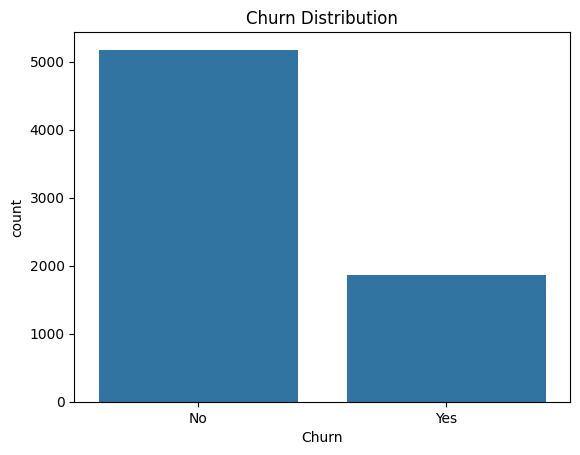

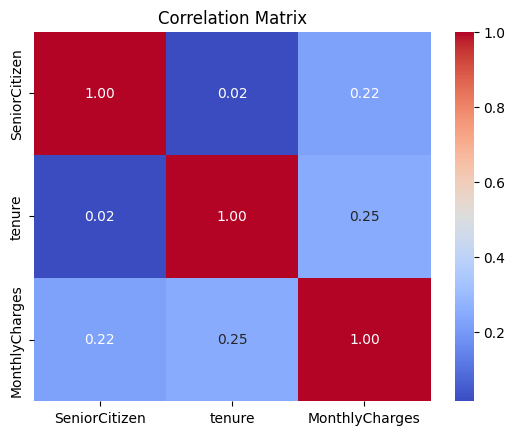

In [3]:

df = pd.read_csv("customer.csv")

print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df['Churn'].value_counts(normalize=True))  # check class balance

# Visualise churn distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

# Correlation heatmap for numerical features
num_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [4]:
# Drop irrelevant column
df.drop('customerID', axis=1, inplace=True)

# Fix TotalCharges (stored as string with spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Encode binary target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Label encode all categorical columns
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [5]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After  SMOTE: {0: 4139, 1: 4139}


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    results[name] = {"model": model, "auc": auc, "y_pred": y_pred, "y_proba": y_proba}
    print(f"\n{'='*40}\n{name}  |  AUC-ROC: {auc:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression  |  AUC-ROC: 0.8389
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Random Forest  |  AUC-ROC: 0.8223
              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.58      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409


XGBoost  |  AUC-ROC: 0.8142
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.71

In [ ]:
param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.05, 0.1],
    'subsample':       [0.8, 1.0],
    'colsample_bytree':[0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1
)
grid.fit(X_train_res, y_train_res)

best_xgb = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV AUC: 0.9364573714793799


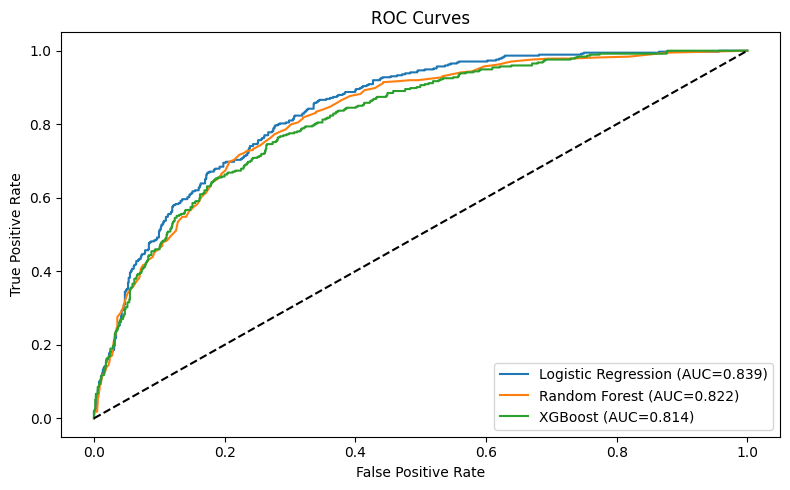

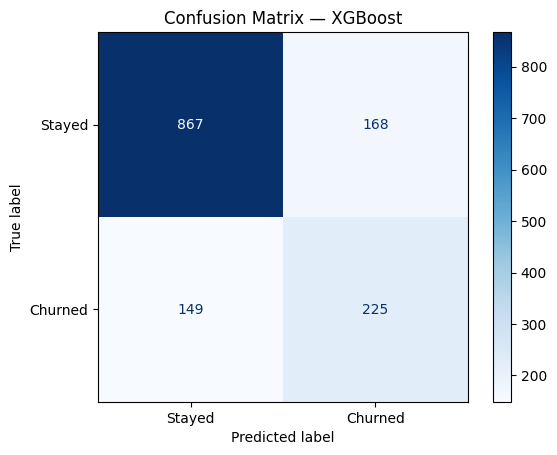

In [7]:
plt.figure(figsize=(8, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

best_pred = results["XGBoost"]["y_pred"]
ConfusionMatrixDisplay.from_predictions(y_test, best_pred,
    display_labels=["Stayed", "Churned"], cmap="Blues")
plt.title("Confusion Matrix — XGBoost")
plt.show()

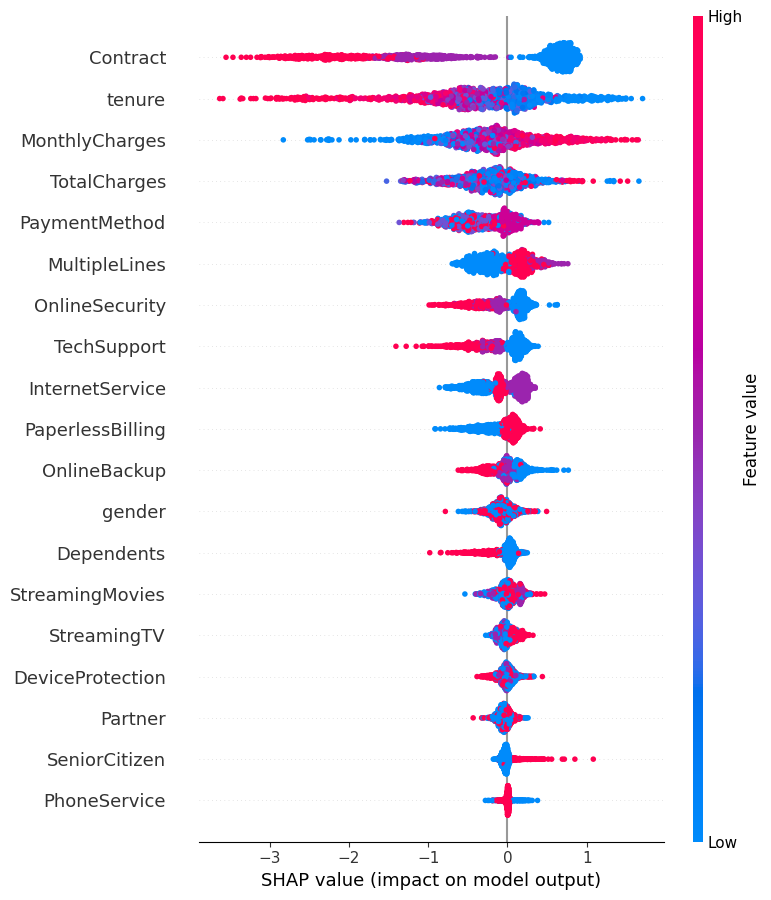

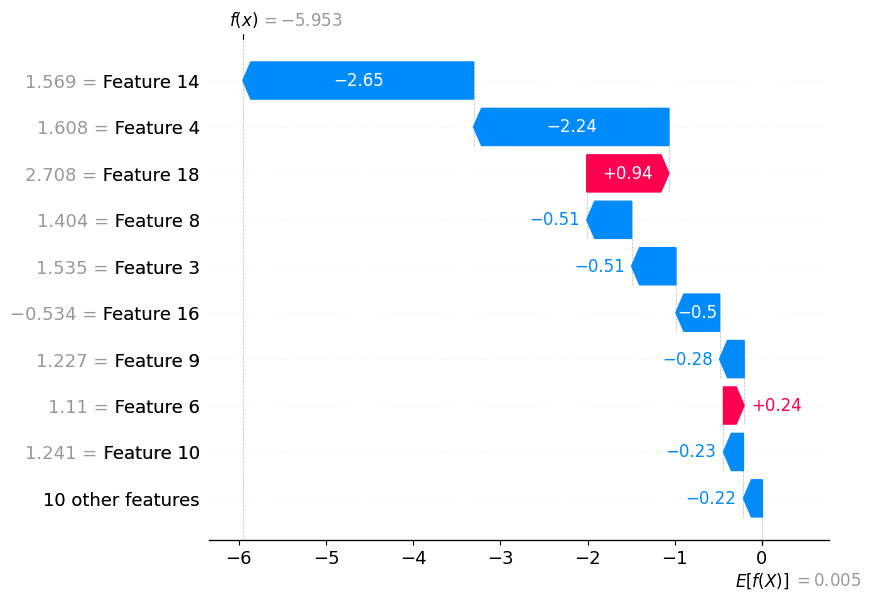

In [8]:
explainer   = shap.Explainer(results["XGBoost"]["model"])
shap_values = explainer(X_test)

# Summary plot — which features drive churn most
shap.summary_plot(shap_values, X_test,
                  feature_names=df.drop('Churn', axis=1).columns.tolist())

# Waterfall plot — why one specific customer is predicted to churn
shap.plots.waterfall(shap_values[0])

In [10]:
import joblib

# Use the already-trained XGBoost from results
best_xgb = results["XGBoost"]["model"]

# Save
joblib.dump(best_xgb, "churn_model.pkl")
joblib.dump(scaler,   "scaler.pkl")

# Load and predict
model  = joblib.load("churn_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

new_customer = scaler_loaded.transform([X_test[0]])
churn_prob   = model.predict_proba(new_customer)[0][1]
print(f"Churn probability: {churn_prob:.2%}")

Churn probability: 99.97%
